In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load csv data into dataframe
import pandas as pd
accounts_df = pd.read_csv('..//data/accounts.csv')
categories_df = pd.read_csv('..//data/categories.csv')
transactions_df = pd.read_csv('..//data/transactions.csv')

# Example plots below shown with account 1 only for visualization

In [3]:
categories_df

,cat_id,name,type
0,1,Rent,expense
1,2,Groceries,expense
2,3,Utilities,expense
3,4,Transport,expense
4,5,Dining Out,expense
5,6,Entertainment,expense
6,7,Healthcare,expense
7,8,Shopping,expense
8,9,Subscriptions,expense
9,10,Salary,income


In [4]:
accounts_df

,account_id,name,balance
0,1,Checking Account,0.0
1,2,Savings Account,0.0


In [3]:
transactions_df

,transaction_id,account_id,cat_id,amount,date,description
0,1,1,1,1500.00,2025-01-01,Monthly rent
1,2,1,3,130.00,2025-01-03,Electric & water
2,3,1,9,43.00,2025-01-05,Streaming & apps
3,4,1,2,84.00,2025-01-24,Grocery run
4,5,1,2,62.33,2025-01-08,Grocery run
...,...,...,...,...,...,...
322,323,2,8,59.89,2025-12-08,Shopping
323,324,1,10,4500.00,2025-12-15,Monthly salary
324,325,1,10,4500.00,2025-12-28,Monthly salary
325,326,1,11,352.38,2025-12-05,Freelance work


In [ ]:
# What we want to visualize
# 1. Total spending by category
# 2. Spending over time
# 3. Account balances



In [5]:
# merging categories and transactions df

transac_cat_merged_df = pd.merge(transactions_df, categories_df, on='cat_id', how='inner')
transac_cat_merged_df


,transaction_id,account_id,cat_id,amount,date,description,name,type
0,1,1,1,1500.00,2025-01-01,Monthly rent,Rent,expense
1,2,1,3,130.00,2025-01-03,Electric & water,Utilities,expense
2,3,1,9,43.00,2025-01-05,Streaming & apps,Subscriptions,expense
3,4,1,2,84.00,2025-01-24,Grocery run,Groceries,expense
4,5,1,2,62.33,2025-01-08,Grocery run,Groceries,expense
...,...,...,...,...,...,...,...,...
322,323,2,8,59.89,2025-12-08,Shopping,Shopping,expense
323,324,1,10,4500.00,2025-12-15,Monthly salary,Salary,income
324,325,1,10,4500.00,2025-12-28,Monthly salary,Salary,income
325,326,1,11,352.38,2025-12-05,Freelance work,Freelance,income


In [6]:
# filtering to get expenses from account 1
account1_expenses = transac_cat_merged_df[(transac_cat_merged_df.account_id == 1) & (transac_cat_merged_df.type=='expense')]
account1_expenses

,transaction_id,account_id,cat_id,amount,date,description,name,type
0,1,1,1,1500.00,2025-01-01,Monthly rent,Rent,expense
1,2,1,3,130.00,2025-01-03,Electric & water,Utilities,expense
2,3,1,9,43.00,2025-01-05,Streaming & apps,Subscriptions,expense
3,4,1,2,84.00,2025-01-24,Grocery run,Groceries,expense
4,5,1,2,62.33,2025-01-08,Grocery run,Groceries,expense
...,...,...,...,...,...,...,...,...
310,311,1,6,88.68,2025-12-05,Entertainment,Entertainment,expense
311,312,1,6,19.27,2025-12-06,Entertainment,Entertainment,expense
312,313,1,6,42.82,2025-12-13,Entertainment,Entertainment,expense
313,314,1,6,42.78,2025-12-15,Entertainment,Entertainment,expense


In [7]:
date = '2025-12-25'
print(date[5:7])

12


In [8]:
month_dic = {
    '01':'January', '02':"February", '03':'March', '04':'April',
    '05':'May', '06':'June', '07':'July', '08':'August', '09':'September',
    '10':'October', '11':'November', '12':'December'
      }

def convert_date(date):
    target = date[5:7]
    return month_dic[target]

print(convert_date('2025-12-25'))

December


In [10]:
account1_expenses['month'] = account1_expenses['date'].map(convert_date)
account1_expenses

/var/folders/jz/mtvslm794cj4p1shg0jcbb040000gn/T/ipykernel_62836/1225895168.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  account1_expenses['month'] = account1_expenses['date'].map(convert_date)


,transaction_id,account_id,cat_id,amount,date,description,name,type,month
0,1,1,1,1500.00,2025-01-01,Monthly rent,Rent,expense,January
1,2,1,3,130.00,2025-01-03,Electric & water,Utilities,expense,January
2,3,1,9,43.00,2025-01-05,Streaming & apps,Subscriptions,expense,January
3,4,1,2,84.00,2025-01-24,Grocery run,Groceries,expense,January
4,5,1,2,62.33,2025-01-08,Grocery run,Groceries,expense,January
...,...,...,...,...,...,...,...,...,...
310,311,1,6,88.68,2025-12-05,Entertainment,Entertainment,expense,December
311,312,1,6,19.27,2025-12-06,Entertainment,Entertainment,expense,December
312,313,1,6,42.82,2025-12-13,Entertainment,Entertainment,expense,December
313,314,1,6,42.78,2025-12-15,Entertainment,Entertainment,expense,December


# Expenses over all time

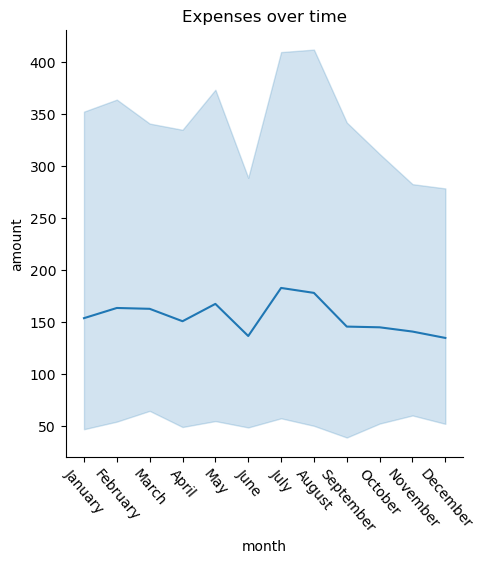

In [11]:
# line plot of expenses over time
sns.relplot(data=account1_expenses, x='month', y='amount', kind='line')
plt.xticks(rotation=310)
plt.title('Expenses over time')
plt.show()

In [13]:
account1_income = transac_cat_merged_df[(transac_cat_merged_df.account_id == 1) & (transac_cat_merged_df.type=='income')]
account1_income.head()

,transaction_id,account_id,cat_id,amount,date,description,name,type
24,25,1,10,4500.00,2025-01-15,Monthly salary,Salary,income
25,26,1,10,4500.00,2025-01-28,Monthly salary,Salary,income
48,49,1,10,4500.00,2025-02-15,Monthly salary,Salary,income
49,50,1,10,4500.00,2025-02-28,Monthly salary,Salary,income
50,51,1,11,1084.68,2025-02-21,Freelance work,Freelance,income


In [14]:
account1_income['month'] = account1_income['date'].map(convert_date)
account1_income.head()

/var/folders/jz/mtvslm794cj4p1shg0jcbb040000gn/T/ipykernel_62836/2248359111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  account1_income['month'] = account1_income['date'].map(convert_date)


,transaction_id,account_id,cat_id,amount,date,description,name,type,month
24,25,1,10,4500.00,2025-01-15,Monthly salary,Salary,income,January
25,26,1,10,4500.00,2025-01-28,Monthly salary,Salary,income,January
48,49,1,10,4500.00,2025-02-15,Monthly salary,Salary,income,February
49,50,1,10,4500.00,2025-02-28,Monthly salary,Salary,income,February
50,51,1,11,1084.68,2025-02-21,Freelance work,Freelance,income,February


# Income over all time

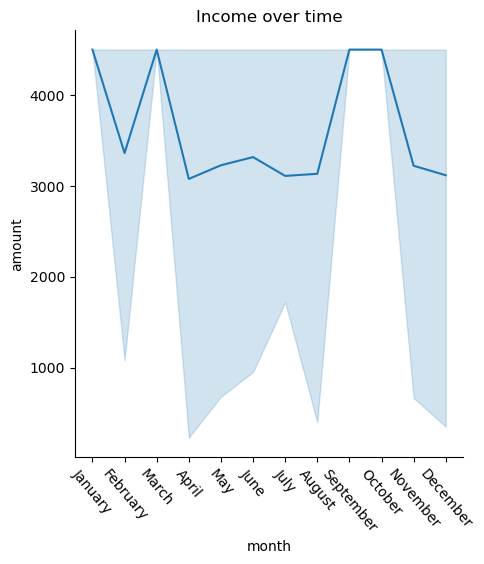

In [15]:
# line plot of income over time
sns.relplot(data=account1_income, x='month', y='amount', kind='line')
plt.xticks(rotation=310)
plt.title('Income over time')
plt.show()

# Separate plots of categories over all time

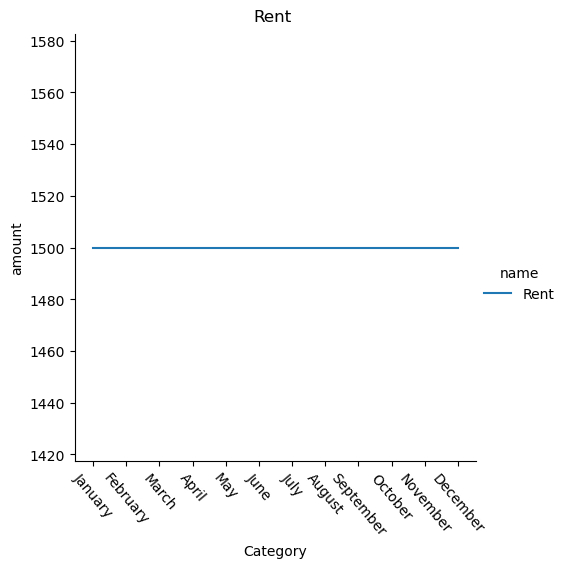

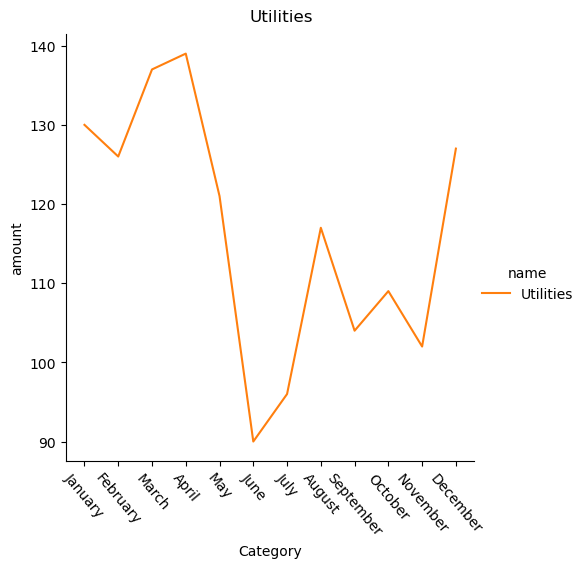

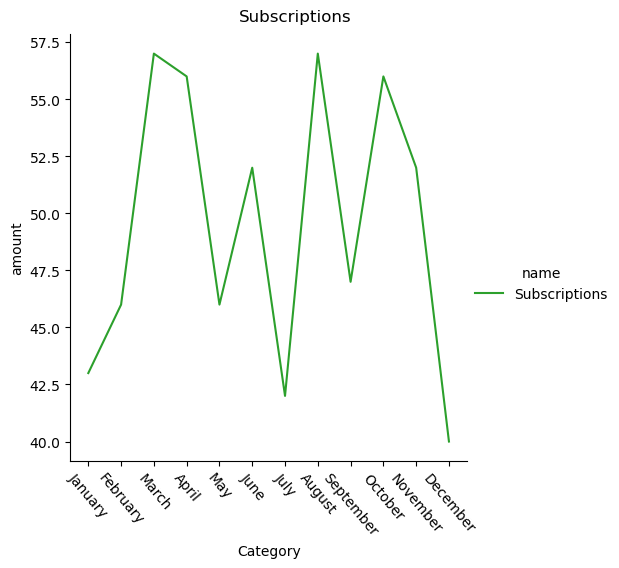

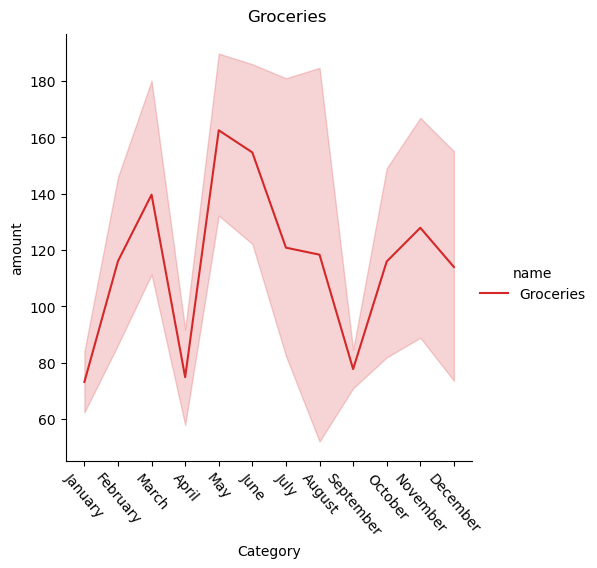

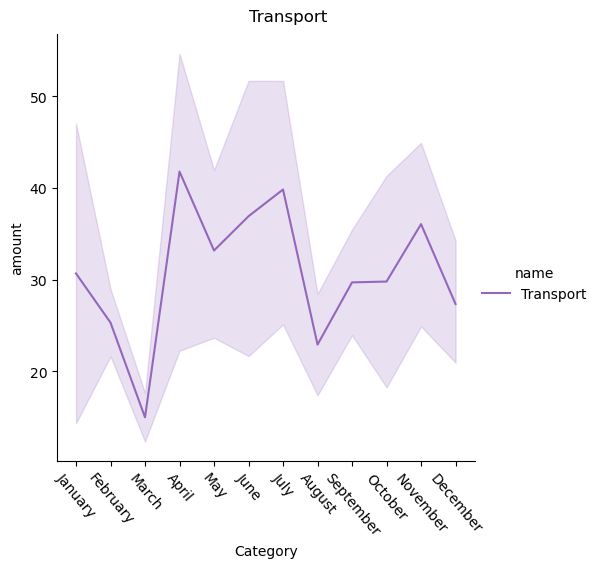

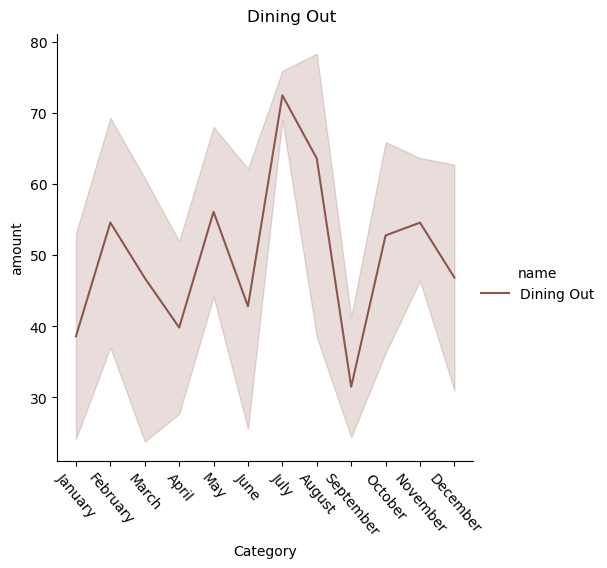

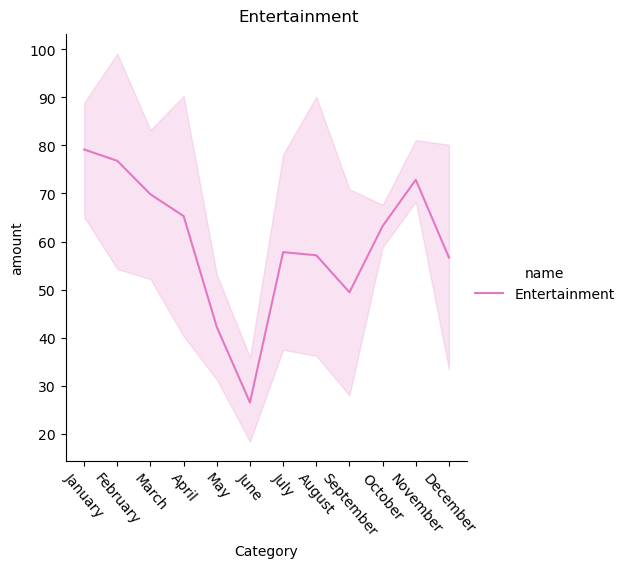

In [16]:
# iterate through data frame to separate categories into separate plots
categories = account1_expenses.name.unique()
palette = sns.color_palette("tab10", len(categories))

for category,color in zip(categories, palette):
        g = sns.relplot(data=account1_expenses[account1_expenses['name']==category], 
            x='month', 
            y='amount', 
            kind='line', 
            hue='name',
            palette=[color] )
        g.set_xticklabels(rotation=310)
        g.set_xlabels('Category')
        g.figure.suptitle(category, y=1.02)
        plt.show()

# Barplot of expense separated by category over all time

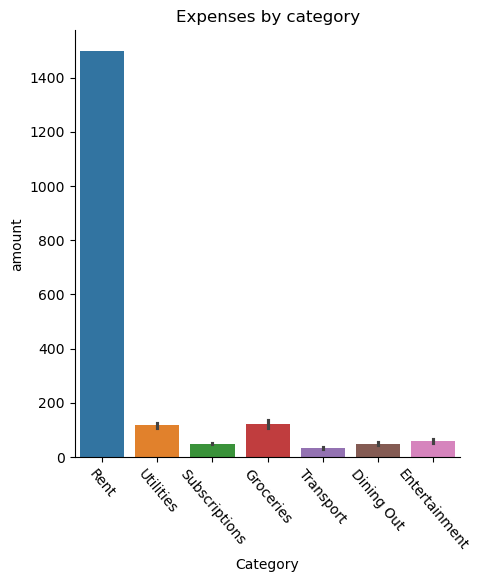

In [17]:
# bar plot to compare expenses by category(overall time)
sns.catplot(data=account1_expenses, x='name', y='amount',kind='bar', hue='name')
plt.xticks(rotation=310)
plt.xlabel('Category')
plt.title('Expenses by category')
plt.show()

# Monthly expenses bar graphs

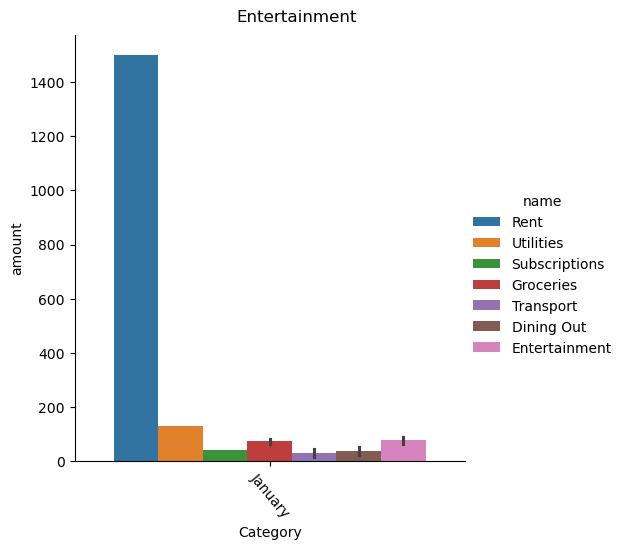

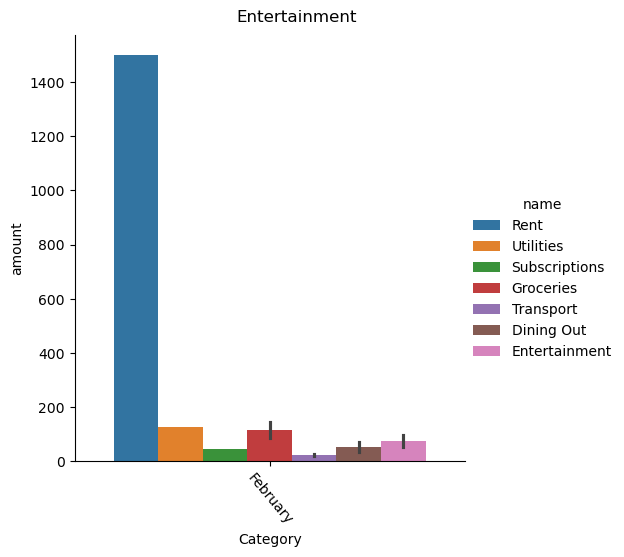

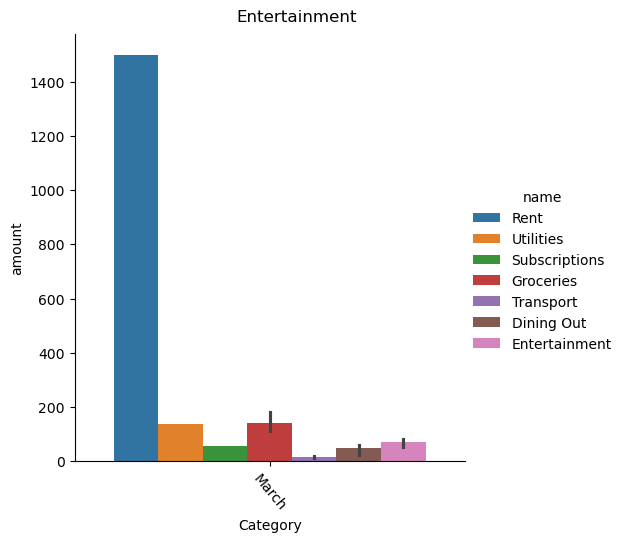

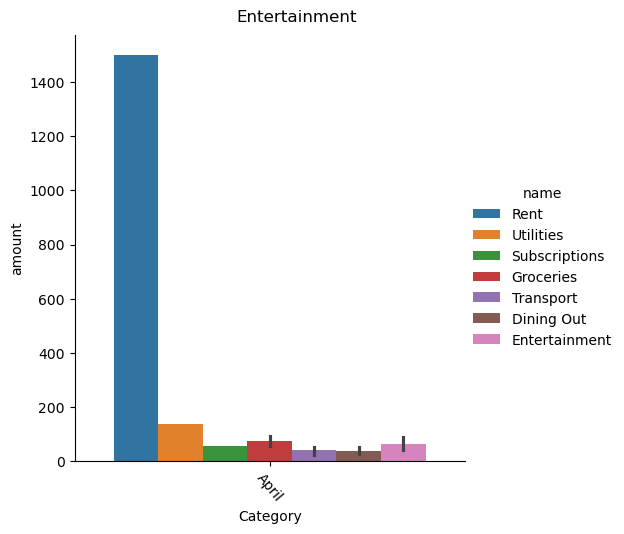

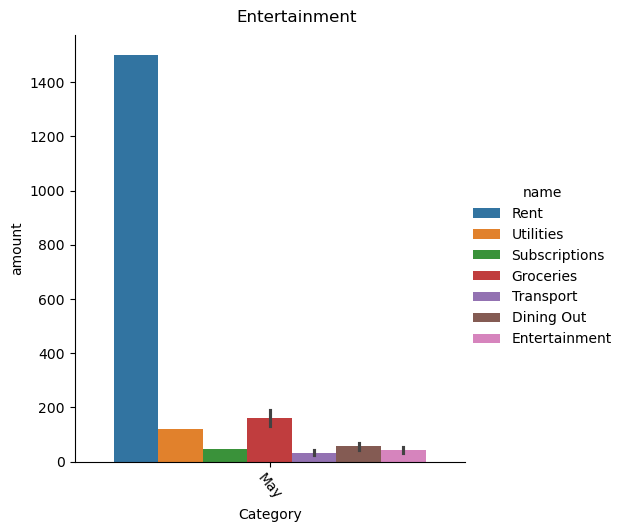

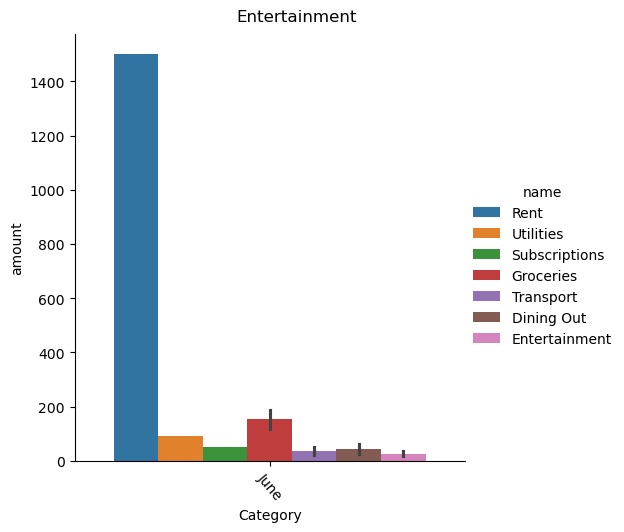

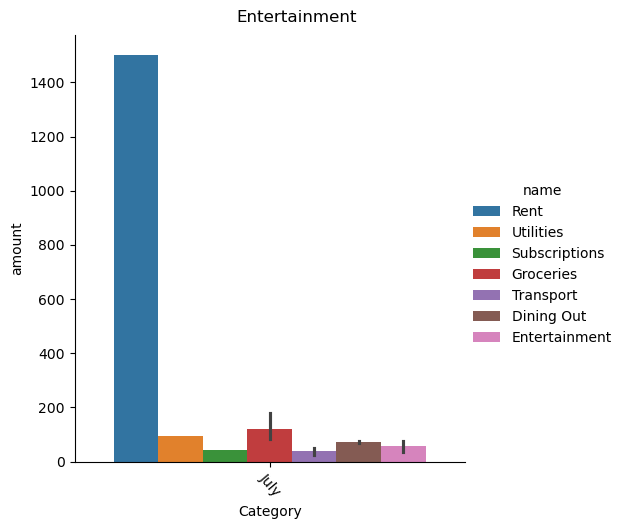

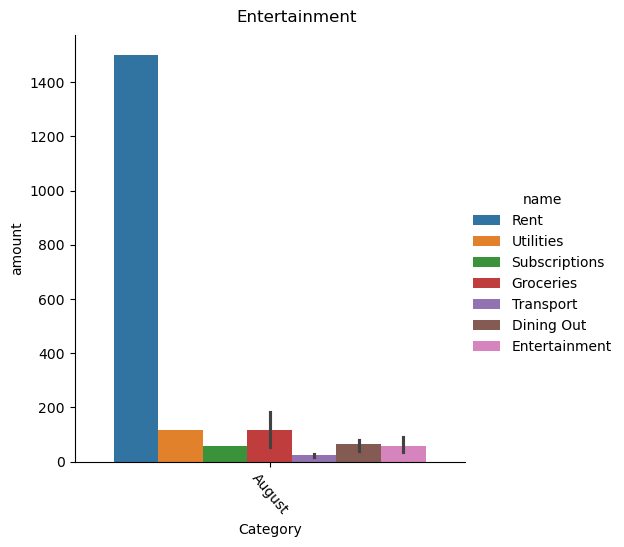

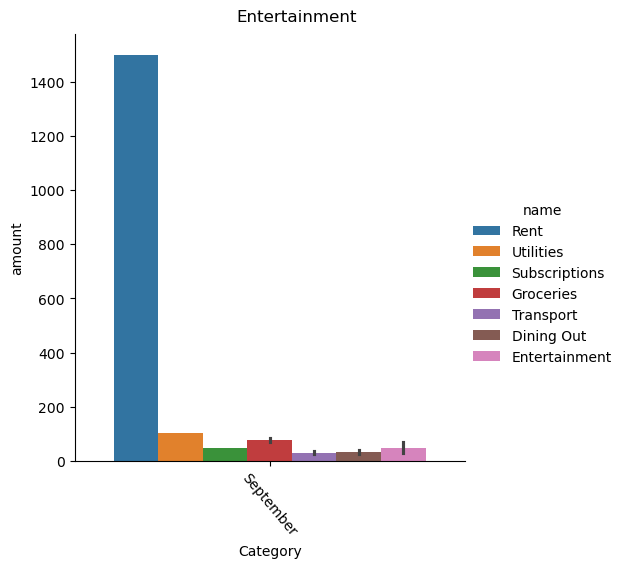

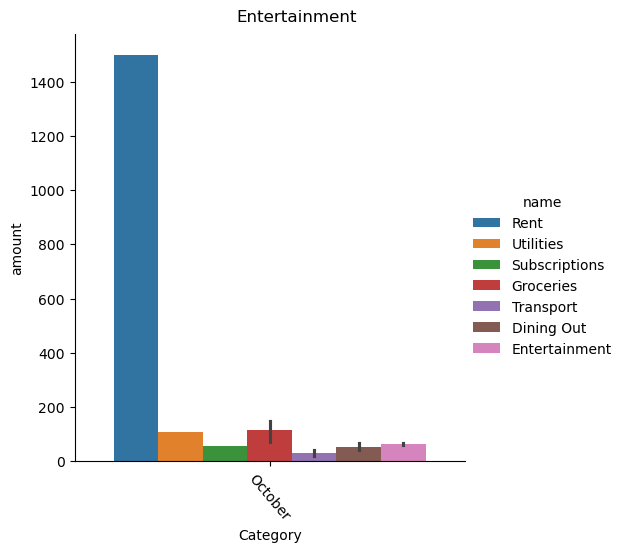

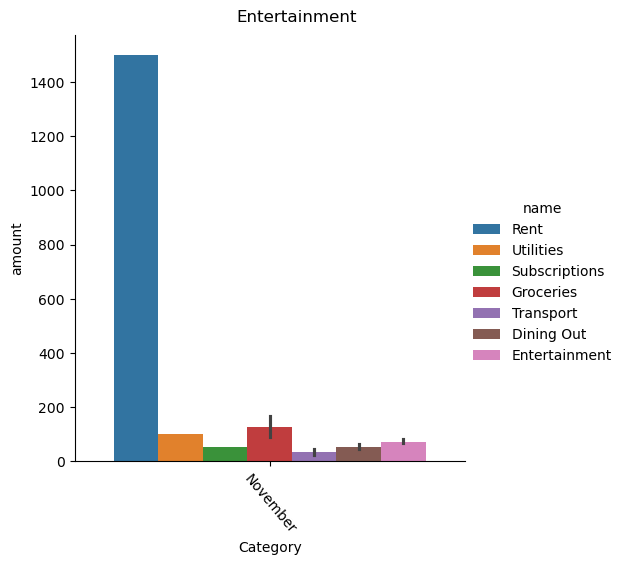

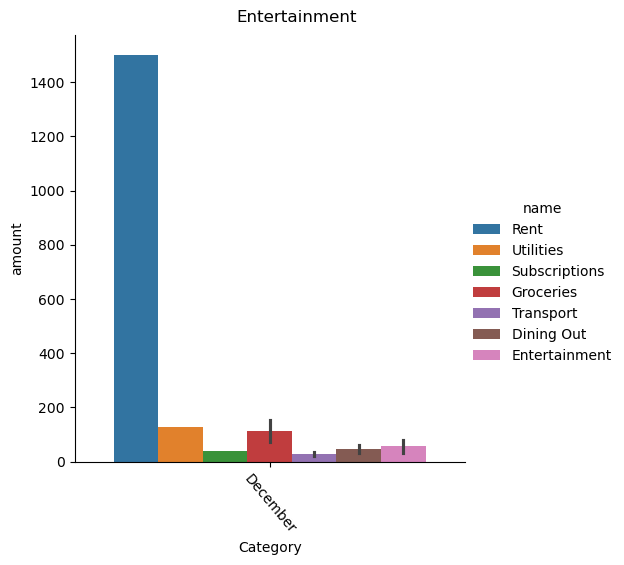

In [18]:
#Monthly expense bar graph
account1_expenses.month.unique()

# iterate through data frame to separate categories into separate plots
months = account1_expenses.month.unique()
palette = sns.color_palette("tab10", len(categories))

for month in months:
        g = sns.catplot(data=account1_expenses[account1_expenses['month']==month], 
            x='month', 
            y='amount', 
            kind='bar', 
            hue='name'
             )
        g.set_xticklabels(rotation=310)
        g.set_xlabels('Category')
        g.figure.suptitle(category, y=1.02)
        plt.show()

# Pie chart of summed expenses for categories

[ 2192.19  2420.49  4620.15 18000.     594.    1296.03  1398.  ]
Index(['Dining Out', 'Entertainment', 'Groceries', 'Rent', 'Subscriptions',
       'Transport', 'Utilities'],
      dtype='object', name='name')


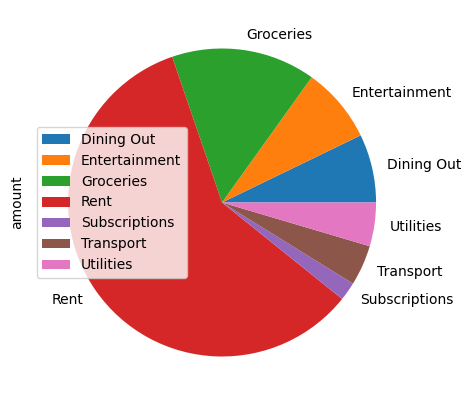

In [19]:
group_expenses = account1_expenses.groupby('name').amount.sum()
print(group_expenses.values)
print(group_expenses.index)
df = pd.DataFrame({'amount': group_expenses.values}, index=group_expenses.index)
plot = df.plot.pie(y='amount', figsize=(5, 5))


# Expense vs Income Bar Chart

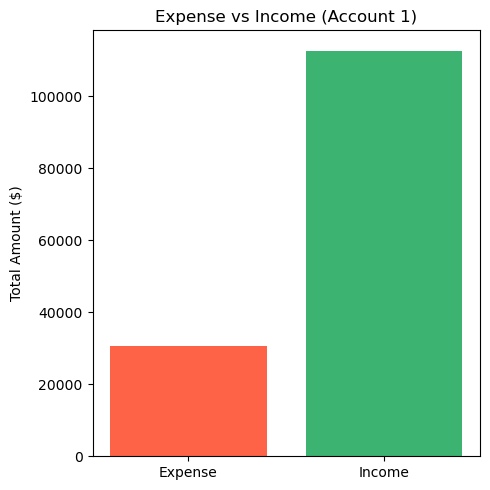

In [20]:
total_expense = account1_expenses['amount'].sum()
total_income = transac_cat_merged_df[(transac_cat_merged_df.account_id == 1) & (transac_cat_merged_df.type == 'income')]['amount'].sum()

fig, ax = plt.subplots(figsize=(5, 5))
ax.bar(['Expense', 'Income'], [total_expense, total_income], color=['tomato', 'mediumseagreen'])
ax.set_title('Expense vs Income (Account 1)')
ax.set_ylabel('Total Amount ($)')
plt.tight_layout()
plt.show()

# Monthly Expenses Bar Chart:

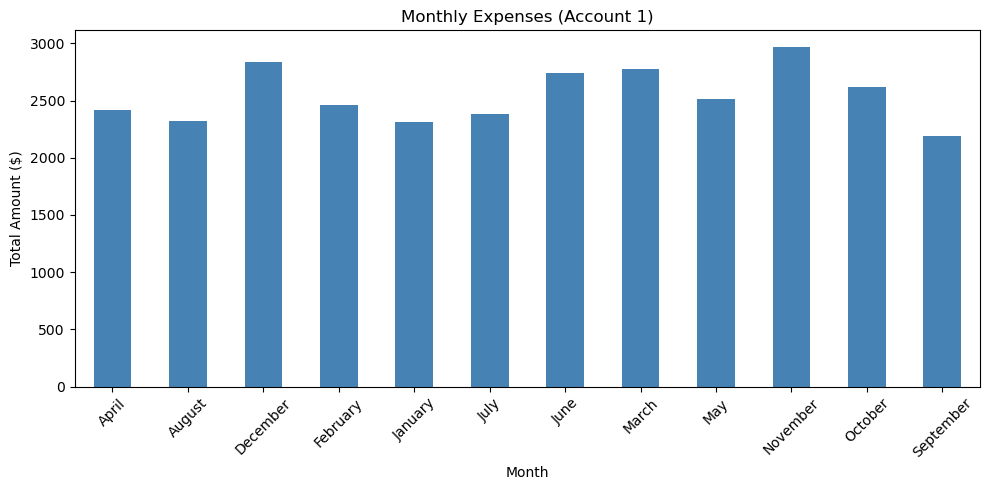

In [21]:
monthly_totals = account1_expenses.groupby('month')['amount'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_totals.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Monthly Expenses (Account 1)')
ax.set_xlabel('Month')
ax.set_ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Spending by Category Bar Chart

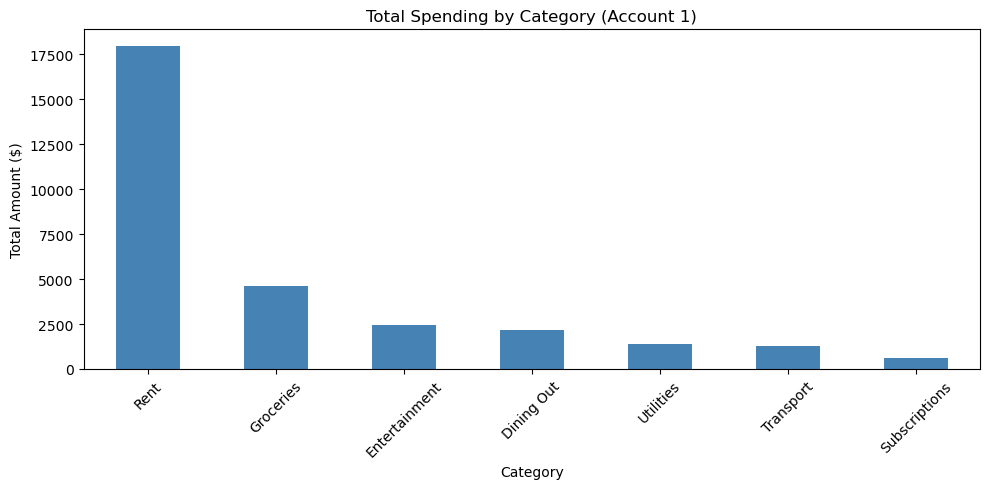

In [22]:
group_expenses = account1_expenses.groupby('name')['amount'].sum().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
group_expenses.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Total Spending by Category (Account 1)')
ax.set_xlabel('Category')
ax.set_ylabel('Total Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Income vs Expense Trend Over Time

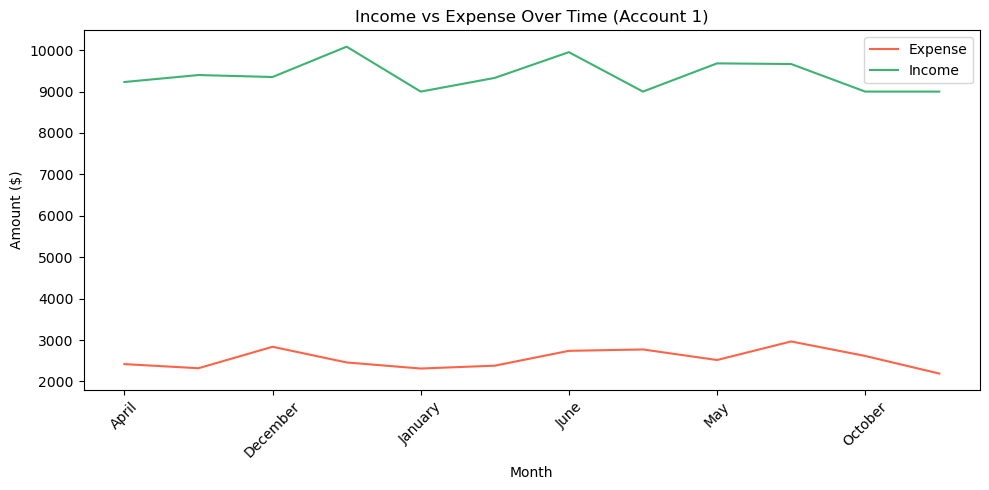

In [23]:
account1_income = transac_cat_merged_df[(transac_cat_merged_df.account_id == 1) & (transac_cat_merged_df.type == 'income')].copy()
account1_income['month'] = account1_income['date'].astype(str).apply(convert_date)

monthly_expense = account1_expenses.groupby('month')['amount'].sum()
monthly_income = account1_income.groupby('month')['amount'].sum()

fig, ax = plt.subplots(figsize=(10, 5))
monthly_expense.plot(kind='line', ax=ax, color='tomato', label='Expense')
monthly_income.plot(kind='line', ax=ax, color='mediumseagreen', label='Income')
ax.set_title('Income vs Expense Over Time (Account 1)')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Cumulative Spending Over Time

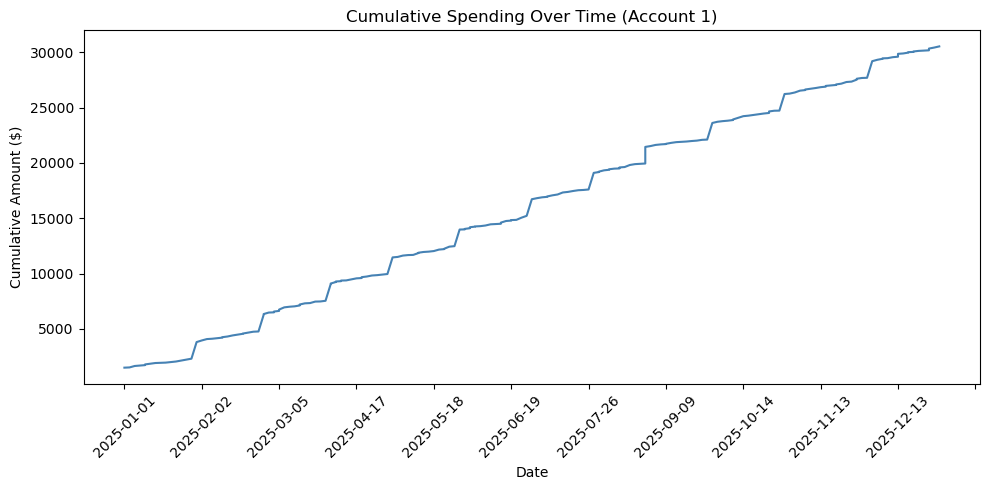

In [ ]:
account1_expenses_sorted = account1_expenses.sort_values('date')
account1_expenses_sorted['cumulative'] = account1_expenses_sorted['amount'].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(account1_expenses_sorted['date'], account1_expenses_sorted['cumulative'], color='steelblue')
ax.set_title('Cumulative Spending Over Time (Account 1)')
ax.set_xlabel('Date')
ax.set_ylabel('Cumulative Amount ($)')
ax.xaxis.set_major_locator(plt.MaxNLocator(12))  #show only 12
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()